# Speed Dating Analysis

This notebook analyzes the Speed Dating Dataset to test **10 specific hypotheses** using
**Binary Logit (Logistic Regression)** models, consolidated into thematic groups — then extends
into a **dynamic structural question** motivated by NFXP-style reasoning.

## Missing Columns and Replacements

Upon inspecting the dataset (`speeddating.csv`), some columns necessary for the hypotheses
are missing. Here is how they are addressed:

- **`income`** *(Missing for H4)*: No income column exists. **Replacement**: We use
  `expected_happy_with_sd_people` as a socio-economic/status satisfaction proxy.
- **`field_o`** *(Missing for H8)*: Partner's career field is absent and we lack IDs to
  self-join. **Replacement**: We use `interests_correlate` (general interest similarity).
- **`goal` / `goal_o`** *(Missing for H9)*: Explicit goal of the night is missing.
  **Replacement**: We use `expected_num_matches` as a proxy for alignment in expectations.

## Mathematical Notation for Binary Logit

For each hypothesis we use a Binary Logit Model. The probability $P$ of a positive
decision ($Decision = 1$) is modelled as:

$$
P(\text{Decision}=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_k X_k)}}
$$

Or equivalently, as log-odds:

$$
\log\!\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1 X_1 + \dots + \beta_k X_k
$$

where $\beta_i$ are the estimated coefficients indicating the effect of each attribute $X_i$.


## Project Structure — Structural Estimation Framework

The diagram below shows how this project uses **structural estimation** to model
individual decision-making in speed dating.

```mermaid
flowchart TD
    A[🧩 Research Problem\nWhat drives a 'Yes' decision\nin speed dating?] --> B

    B[Why Structural Estimation?\nOLS ignores binary outcomes\nLinear probability violates\nprobability bounds 0-1\nNeed to model latent utility] --> C

    C[Structural Model Choice\n🔵 Binary Logit / Logistic Regression\nAssumes each person has a latent\nutility U* — they say Yes if U* > 0\nU* = Xβ + ε where ε ~ Logistic] --> D

    D[Data Layer\nSpeed Dating Dataset\n8,378 observations · 123 variables\nCleaned: stripped b-string artefacts\nConverted numeric columns] --> E

    E{3 Consolidated Hypothesis Groups\n+ 1 Dynamic Question} --> G1 & G2 & G3 & DQ

    G1[Group A: Appearance & Personality\nH1 Attractiveness vs Personality · H3 Gender × Attractiveness\nH6 Attractiveness Gap]
    G2[Group B: Compatibility & Similarity\nH5 Same-Race · H7 Shared Interests\nH8 Career Proxy · H10 Intel × Ambition]
    G3[Group C: Expectations & Context\nH2 Age Difference · H4 Status Proxy\nH9 Goal Alignment]
    DQ[🔬 Dynamic Question\nDo people lower their standards\nwhen they expect fewer\nfuture opportunities?]

    G1 & G2 & G3 & DQ --> F

    F[Identification Strategy\nMLE maximises log-likelihood\nCoefficients = partial effects on log-odds\nSignificance tested via Wald z-test p<0.05\nModel fit via McFadden Pseudo-R²] --> G

    G[🎯 Findings & Policy\nWhich traits causally shift\nthe probability of a Yes?\nActionable recommendations\nExternal validation vs SwipeStats]

    style A fill:#4F46E5,color:#fff
    style C fill:#7C3AED,color:#fff
    style F fill:#0891B2,color:#fff
    style G fill:#059669,color:#fff
    style B fill:#1E40AF,color:#fff
    style DQ fill:#DC2626,color:#fff
```

### Why Structural Estimation (Binary Logit) instead of OLS?

| Issue | OLS | Binary Logit |
|---|---|---|
| Outcome is 0/1 | Predicts values outside [0,1] | Always predicts valid probabilities |
| Latent utility | Ignores underlying preference | Models $U^* = X\beta + \varepsilon$ |
| Error distribution | Assumes normal errors | Assumes logistic errors — correct for binary |
| Interpretation | Marginal change in $Y$ | Marginal change in **log-odds** of $Y=1$ |
| Structural consistency | Reduced-form only | Derives from a utility-maximisation model |

The **logit model is structurally justified**: each participant says *Yes* if and only if
their unobserved utility $U^* > 0$. MLE recovers the preference parameters $\beta$ that
best explain observed choices — which is exactly what structural estimation does.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')


## 1. Load the Dataset

The CSV was exported in a way that serialised Python `bytes` objects as string literals
(e.g. `b'female'`). The cleaning step below strips those `b'...'` wrappers so every
value is a plain string, then converts columns to numeric wherever more than half the
non-null values parse successfully.


In [2]:
df_raw = pd.read_csv('./archive/speeddating.csv', encoding='utf-8')
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)


Raw shape: (8378, 123)


,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,b'',1.0,b'female',21.0,27.0,6.0,b'[4-6]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'0',b'0'
1,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,5.0,b'[6-8]',b'[5-6]',1.0,b'1',b'0',b'0'
2,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'Asian/Pacific Islander/Asian-American',b'1',...,b'[0-3]',b'[3-5]',7.0,NaN,b'[6-8]',b'[0-4]',1.0,b'1',b'1',b'1'


## 2. Data Cleaning

### 2.1 Strip `b'...'` byte-string literals

In [3]:
def strip_b_string(val):
    """Remove Python bytes repr artefacts: b'value' → value"""
    if isinstance(val, str) and val.startswith("b'") and val.endswith("'"):
        return val[2:-1]
    return val

df = df_raw.apply(lambda col: col.map(strip_b_string))
print("Sample after stripping:")
print(df[['gender', 'race', 'field', 'samerace']].head(3))


Sample after stripping:
   gender                                   race field samerace
0  female  Asian/Pacific Islander/Asian-American   Law        0
1  female  Asian/Pacific Islander/Asian-American   Law        0
2  female  Asian/Pacific Islander/Asian-American   Law        1


### 2.2 Convert to numeric where appropriate

In [4]:
for col in df.columns:
    converted = pd.to_numeric(df[col], errors='coerce')
    non_null = df[col].notna().sum()
    converted_non_null = converted.notna().sum()
    if non_null > 0 and (converted_non_null / non_null) > 0.5:
        df[col] = converted

numeric_cols  = df.select_dtypes('number').columns.tolist()
category_cols = [c for c in df.columns if c not in numeric_cols]

print(f"Numeric columns  : {len(numeric_cols)}")
print(f"Categorical columns: {len(category_cols)}")
print(f"\nCategorical cols kept as strings: {category_cols[:10]} ...")


Numeric columns  : 63
Categorical columns: 60

Categorical cols kept as strings: ['has_null', 'gender', 'd_d_age', 'race', 'race_o', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'd_pref_o_attractive', 'd_pref_o_sincere'] ...


### 2.3 Dataset overview after cleaning

In [5]:
print(f"Shape: {df.shape}")
print(f"\nMissing values (top 15 columns with most NaNs):")
print(df.isnull().sum().sort_values(ascending=False).head(15))
print(f"\nTarget column 'decision' value counts:")
print(df['decision'].value_counts())


Shape: (8378, 123)

Missing values (top 15 columns with most NaNs):
expected_num_interested_in_me    6578
expected_num_matches             1173
shared_interests_o               1076
shared_interests_partner         1067
ambitous_o                        722
ambition_partner                  712
met                               375
funny_o                           360
funny_partner                     350
guess_prob_liked                  309
intelligence_o                    306
intelligence_partner              296
sinsere_o                         287
sincere_partner                   277
like                              240
dtype: int64

Target column 'decision' value counts:
decision
0    4860
1    3518
Name: count, dtype: int64


In [6]:
df.describe()

,wave,age,age_o,d_age,samerace,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,...,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,like,guess_prob_liked,met,decision,decision_o,match
count,8378.000000,8283.000000,8274.000000,8378.000000,8378.000000,8299.000000,8299.000000,8289.000000,8289.000000,8289.000000,...,8220.000000,8277.000000,1800.000000,7205.000000,8138.000000,8069.000000,8003.000000,8378.000000,8378.000000,8378.000000
mean,11.350919,26.358928,26.364999,4.185605,0.395799,3.784793,3.651645,22.495347,17.396867,20.270759,...,0.196010,5.534131,5.570556,3.207814,6.134087,5.207523,0.049856,0.419909,0.419551,0.164717
std,5.995903,3.566763,3.563648,4.596171,0.489051,2.845708,2.805237,12.569802,7.044003,6.782895,...,0.303539,1.734059,4.762569,2.444813,1.841285,2.129565,0.282168,0.493573,0.493515,0.370947
min,1.000000,18.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,-0.830000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,24.000000,24.000000,1.000000,0.000000,1.000000,1.000000,15.000000,15.000000,17.390000,...,-0.020000,5.000000,2.000000,2.000000,5.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,26.000000,26.000000,3.000000,0.000000,3.000000,3.000000,20.000000,18.370000,20.000000,...,0.210000,6.000000,4.000000,3.000000,6.000000,5.000000,0.000000,0.000000,0.000000,0.000000
75%,15.000000,28.000000,28.000000,5.000000,1.000000,6.000000,6.000000,25.000000,20.000000,23.810000,...,0.430000,7.000000,8.000000,4.000000,7.000000,7.000000,0.000000,1.000000,1.000000,0.000000
max,21.000000,55.000000,55.000000,37.000000,1.000000,10.000000,10.000000,100.000000,60.000000,50.000000,...,0.910000,10.000000,20.000000,18.000000,10.000000,10.000000,8.000000,1.000000,1.000000,1.000000


## 3. Modelling Helper

A single reusable function runs every logit model, prints the full summary,
and interprets each coefficient in plain language.


In [7]:
def run_logit_model(df, features, target='decision', title=''):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")

    model_data = df[[target] + features].dropna()

    if model_data.empty:
        print("No complete cases available for these features.")
        return

    X = sm.add_constant(model_data[features])
    y = model_data[target]

    try:
        model = sm.Logit(y, X).fit(disp=0)
        print(model.summary())

        print("\n--- Interpretation ---")
        for feature in features:
            coef = model.params[feature]
            pval = model.pvalues[feature]
            if pval < 0.05:
                direction = "increases" if coef > 0 else "decreases"
                print(
                    f"  [{feature}]: SIGNIFICANT (p={pval:.4f}) — "
                    f"an increase {direction} the likelihood of a "
                    f"positive decision (coef={coef:.4f})."
                )
            else:
                print(
                    f"  [{feature}]: NOT significant (p={pval:.4f}) — "
                    f"cannot conclude it affects the decision."
                )
        return model
    except Exception as exc:
        print(f"Model error: {exc}")


---
## 4. Group A — Appearance & Personality

> **Unifying question:** How much does *how someone looks and presents themselves*
> drive a Yes — and does it differ by gender or by the attractiveness gap between partners?

This group consolidates **H1**, **H3**, and **H6**, which all centre on physical
appearance as a driver of romantic selection. Together they answer:
- Which appearance/personality traits predict a Yes? (H1)
- Does gender moderate how strongly looks matter? (H3)
- Does attractiveness *parity* matter, not just absolute attractiveness? (H6)

All three models use the same structural scaffold: latent utility
$U^* = X\beta + \varepsilon$, $\varepsilon \sim \text{Logistic}$, with MLE recovering $\beta$.


### H1 — Attractiveness vs. Personality

**Research question:** Among appearance and personality ratings, which attributes
independently shift the probability of saying Yes?

**Model:**

$$
\log\!\left(\frac{P}{1-P}\right)
  = \beta_0
  + \beta_1(\text{Attractiveness})
  + \beta_2(\text{Sincere})
  + \beta_3(\text{Intelligence})
  + \beta_4(\text{Funny})
$$

We use the partner ratings: `attractive_partner`, `sincere_partner`,
`intelligence_partner`, `funny_partner`.


In [8]:
h1_features = ['attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner']
run_logit_model(df, h1_features, title='H1: Attractiveness vs Personality')



  H1: Attractiveness vs Personality
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 7915
Model:                          Logit   Df Residuals:                     7910
Method:                           MLE   Df Model:                            4
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2310
Time:                        19:37:21   Log-Likelihood:                -4159.4
converged:                       True   LL-Null:                       -5408.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.3503      0.174    -30.836      0.000      -5.690      -5.010
attractive_partner       0.5623      0.020     28.405      0.000

#### Interpretation of H1

From the logit table (Pseudo-R² = 0.231, n = 7,915, LLR p < 0.001):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `attractive_partner` | **+0.5623** | < 0.001 | ✅ Yes |
| `sincere_partner` | **−0.0698** | 0.002 | ✅ Yes |
| `intelligence_partner` | −0.0311 | 0.226 | ❌ No |
| `funny_partner` | **+0.3371** | < 0.001 | ✅ Yes |

- **Attractiveness (coef = +0.5623, p < 0.001):** The strongest positive predictor. Each one-unit increase in how attractive a participant rates their partner increases the log-odds by 0.56. Physical appearance is the dominant driver — this model achieves the highest Pseudo-R² of all ten hypotheses (0.231).
- **Funny (coef = +0.3371, p < 0.001):** The second significant positive predictor. Humour raises the probability of a Yes — personality matters, but less than looks.
- **Sincere (coef = −0.0698, p = 0.002):** Counterintuitively negative. High sincerity scores are associated with partners perceived as "too earnest" or lacking romantic excitement in a fast-paced speed-dating context.
- **Intelligence (coef = −0.0311, p = 0.226):** Not significant once attractiveness and humour are controlled for.

**Overall:** Attractiveness dominates, followed by funniness. Pseudo-R² = 0.231 is the highest across all models.


### H3 — Gender Moderates Attractiveness

**Research question:** Do men and women weight partner attractiveness differently?

**Model:**

$$
\log\!\left(\frac{P}{1-P}\right)
  = \beta_0
  + \beta_1(\text{Gender})
  + \beta_2(\text{Attractive})
  + \beta_3(\text{Gender} \times \text{Attractive})
$$

We create an interaction term `gender_x_attractive` to test whether attractiveness
matters differently for each gender. Gender is encoded as 0 (female) / 1 (male).

**Connection to H1:** H1 showed attractiveness is the dominant driver *on average*.
H3 asks whether that average conceals heterogeneous preferences across genders —
a richer structural model with a preference parameter that varies by agent type.


In [9]:
df_h3 = df.copy()
df_h3['gender_num'] = pd.to_numeric(
    df_h3['gender'].map({'female': 0, 'male': 1}), errors='coerce'
).fillna(pd.to_numeric(df_h3['gender'], errors='coerce'))

df_h3['gender_x_attractive'] = df_h3['gender_num'] * df_h3['attractive_partner']

h3_features = ['gender_num', 'attractive_partner', 'gender_x_attractive']
run_logit_model(df_h3, h3_features, title='H3: Gender Influences (Interaction Term)')



  H3: Gender Influences (Interaction Term)
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 8176
Model:                          Logit   Df Residuals:                     8172
Method:                           MLE   Df Model:                            3
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2061
Time:                        19:37:22   Log-Likelihood:                -4433.6
converged:                       True   LL-Null:                       -5584.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -4.2485      0.155    -27.400      0.000      -4.552      -3.945
gender_num             -0.8577      0.239     -3.595      0.

#### Interpretation of H3

From the logit table (Pseudo-R² = 0.206, n = 8,176, LLR p < 0.001):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `gender_num` (male=1) | **−0.8577** | < 0.001 | ✅ Yes |
| `attractive_partner` | **+0.6011** | < 0.001 | ✅ Yes |
| `gender_x_attractive` | **+0.1716** | < 0.001 | ✅ Yes |

- **Gender baseline (coef = −0.8577):** At zero attractiveness, males have lower baseline log-odds of saying Yes — men are more selective when rating less-attractive partners.
- **Attractiveness for females (coef = +0.6011):** Each unit increase in partner attractiveness raises log-odds by 0.60 for women.
- **Interaction `gender_x_attractive` (coef = +0.1716):** Positive and highly significant. Men's total attractiveness effect = 0.6011 + 0.1716 = **+0.7727** — about **29% larger** than the female effect. Men weight physical attractiveness more heavily.

**Structural insight:** The interaction term is a *heterogeneous preference parameter* — it tells us the utility function θ differs across genders, requiring a model that allows agent-type-specific coefficients.

**Overall:** Gender significantly moderates the attractiveness effect. H3 deepens H1 by revealing whose decisions are most driven by looks.


### H6 — Attractiveness Gap (Matching Hypothesis)

**Research question:** Does attractiveness *parity* between self and partner matter, not just absolute attractiveness?

**Model:**

$$
\log\!\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1\,|\text{Self Attractive} - \text{Partner Attractive}|
$$

We compute the absolute gap between self-perceived attractiveness (`attractive`) and
how attractive the participant rated their partner (`attractive_partner`).

**Connection to H1 and H3:** H1 showed raw attractiveness matters. H6 extends this:
what if people also compare themselves to the partner? This tests the sociological
*matching hypothesis* — that people prefer partners of comparable desirability.


In [10]:
df['attractiveness_gap'] = (df['attractive'] - df['attractive_partner']).abs()

h6_features = ['attractiveness_gap']
run_logit_model(df, h6_features, title='H6: Attractiveness Gap')



  H6: Attractiveness Gap
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 8079
Model:                          Logit   Df Residuals:                     8077
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:                 0.03489
Time:                        19:37:28   Log-Likelihood:                -5324.1
converged:                       True   LL-Null:                       -5516.5
Covariance Type:            nonrobust   LLR p-value:                 1.065e-85
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2429      0.036      6.817      0.000       0.173       0.313
attractiveness_gap    -0.2824      0.015    -18.562      0.000      -0.312      -

#### Interpretation of H6

From the logit table (Pseudo-R² = 0.035, n = 8,079, LLR p < 0.001):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `attractiveness_gap` | **−0.2824** | < 0.001 | ✅ Yes |

- **Attractiveness gap (coef = −0.2824, p < 0.001):** Highly significant and negative. Each one-unit increase in the absolute gap reduces the log-odds of a Yes by 0.28 — a **25% reduction in odds** ($e^{-0.2824} \approx 0.754$).
- **Symmetry:** The absolute gap means discomfort works both ways — feeling out-of-league *or* feeling above the partner both reduce positivity.
- **The matching hypothesis is confirmed:** People want a partner at a *comparable* attractiveness level, not just a maximally attractive one.

**Group A Summary:** Appearance drives decisions (H1), men are more appearance-sensitive (H3), and people seek attractiveness parity not just attractiveness maximisation (H6). Together these three findings fully characterise the role of physical appearance in the utility function.


---
## 5. Group B — Compatibility & Similarity

> **Unifying question:** Beyond physical appearance, does *likeness* between partners —
> in race, interests, career, or cognitive traits — improve the probability of a Yes?

This group consolidates **H5**, **H7**, **H8**, and **H10**, which test whether
similarity along different dimensions drives positive decisions. Together they map
the *horizontal preference* structure of the utility function — preferences for
partners similar to oneself, independent of absolute trait levels.

| Hypothesis | Similarity Dimension | Expected Direction |
|---|---|---|
| H5 | Racial homophily | Positive (in-group preference) |
| H7 | Shared interests / hobbies | Positive (compatibility signal) |
| H8 | Career / field overlap (proxy) | Positive (shared context) |
| H10 | Intelligence × Ambition (interaction) | Positive main effects; negative interaction |


### H5 — Same-Race Preference

**Research question:** Do people show in-group preference based on race?

**Model:**
$$
\log\!\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1(\text{Same Race})
$$

We use the `samerace` binary column (already numeric after cleaning).


In [11]:
h5_features = ['samerace']
run_logit_model(df, h5_features, title='H5: Same-Race Preference')



  H5: Same-Race Preference
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 8378
Model:                          Logit   Df Residuals:                     8376
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:               0.0003897
Time:                        19:37:29   Log-Likelihood:                -5697.0
converged:                       True   LL-Null:                       -5699.2
Covariance Type:            nonrobust   LLR p-value:                   0.03507
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3610      0.029    -12.637      0.000      -0.417      -0.305
samerace       0.0953      0.045      2.108      0.035       0.007       0.184

--- Interpretation ---


#### Interpretation of H5

From the logit table (Pseudo-R² = 0.0004, n = 8,378, LLR p = 0.035):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `samerace` | **+0.0953** | 0.035 | ✅ Yes |

- **Same-race (coef = +0.0953):** Statistically significant. Same-race pairs are approximately $e^{0.0953} \approx 1.10$ times — **10% more likely** — to result in a Yes.
- **Effect size is small:** Pseudo-R² = 0.0004. Race similarity is a real but negligible predictor; the decision is dominated by attractiveness and interests.
- **Sociological implication:** Consistent with homophily, but too weak to be actionable in isolation.


### H7 — Shared Interests

**Research question:** Does perceiving shared hobbies and values with a partner increase the probability of a Yes?

**Model:**
$$
\log\!\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1(\text{Shared Interests})
$$

We use `shared_interests_partner`.


In [12]:
h7_features = ['shared_interests_partner']
run_logit_model(df, h7_features, title='H7: Shared Interests')



  H7: Shared Interests
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 7311
Model:                          Logit   Df Residuals:                     7309
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.1279
Time:                        19:37:29   Log-Likelihood:                -4362.4
converged:                       True   LL-Null:                       -5002.1
Covariance Type:            nonrobust   LLR p-value:                3.391e-280
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -2.7788      0.085    -32.660      0.000      -2.946      -2.612
shared_interests_partner     0.4467      0.014     31.667      0.

#### Interpretation of H7

From the logit table (Pseudo-R² = 0.128, n = 7,311, LLR p < 0.001):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `shared_interests_partner` | **+0.4467** | < 0.001 | ✅ Yes |

- **Shared interests (coef = +0.4467):** Highly significant. Each +1 unit raises log-odds by 0.45. Pseudo-R² = 0.128 — the **second highest** of all models, behind H1.
- **Mechanism:** Even in 3–5 minutes, common-ground topics generate rapport that directly translates to a Yes vote. Shared interests are the strongest *non-appearance* predictor.

**Contrast with H5:** Racial similarity (a demographic fact) has near-zero predictive power; *perceived* interest similarity (an in-conversation signal) has strong predictive power. This confirms that *horizontal compatibility as experienced in the moment* — not demographic similarity in the abstract — drives matching.


### H8 — Career / Field Similarity (Interest Correlation Proxy)

**Research question:** Does sharing a professional background improve matching odds?

**Model:**
$$
\log\!\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1(\text{Interests Correlate})
$$

`field_o` (partner's career field) is missing. We replace it with `interests_correlate`,
the calculated correlation between participant interest profiles.


In [13]:
h8_features = ['interests_correlate']
run_logit_model(df, h8_features, title='H8: Interest Correlation (Proxy for Field Similarity)')



  H8: Interest Correlation (Proxy for Field Similarity)
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 8220
Model:                          Logit   Df Residuals:                     8218
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:               0.0002522
Time:                        19:37:30   Log-Likelihood:                -5590.1
converged:                       True   LL-Null:                       -5591.5
Covariance Type:            nonrobust   LLR p-value:                   0.09308
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.3478      0.027    -13.032      0.000      -0.400      -0.296
interests_correlate     0.1237      0.074      

#### Interpretation of H8

From the logit table (Pseudo-R² = 0.0003, n = 8,220, LLR p = 0.093):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `interests_correlate` | +0.1237 | 0.093 | ❌ No |

- **Not significant (p = 0.093):** We fail to reject the null hypothesis. The proxy is too abstract — it measures statistical correlation across a rating profile, not actual career overlap.
- **Contrast with H7:** H7 (perceived shared interests, self-reported) is highly significant; H8 (statistically computed interest correlation) is not. This tells us *self-perceived compatibility*, formed in conversation, matters far more than objective similarity metrics.
- **Proxy limitation:** A direct career-match variable (unavailable here) might yield a different result.


### H10 — Intelligence × Ambition Trade-off

**Research question:** Do intelligence and ambition independently predict a Yes, or do they substitute for each other at high levels?

**Model:**
$$
\log\!\left(\frac{P}{1-P}\right)
  = \beta_0
  + \beta_1(\text{Intelligence})
  + \beta_2(\text{Ambition})
  + \beta_3(\text{Intelligence} \times \text{Ambition})
$$

We add an interaction term `intelligence_partner × ambition_partner` to test
whether high ambition changes how much intelligence matters.


In [14]:
df['intel_x_ambition'] = df['intelligence_partner'] * df['ambition_partner']

h10_features = ['intelligence_partner', 'ambition_partner', 'intel_x_ambition']
run_logit_model(df, h10_features, title='H10: Intelligence / Ambition Trade-off')



  H10: Intelligence / Ambition Trade-off
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 7633
Model:                          Logit   Df Residuals:                     7629
Method:                           MLE   Df Model:                            3
Date:                Sun, 17 May 2026   Pseudo R-squ.:                 0.03936
Time:                        19:37:30   Log-Likelihood:                -5003.5
converged:                       True   LL-Null:                       -5208.5
Covariance Type:            nonrobust   LLR p-value:                 1.476e-88
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -4.2320      0.423    -10.013      0.000      -5.060      -3.404
intelligence_partner     0.4419      0.058      7.593      

#### Interpretation of H10

From the logit table (Pseudo-R² = 0.039, n = 7,633, LLR p < 0.001):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `intelligence_partner` | **+0.4419** | < 0.001 | ✅ Yes |
| `ambition_partner` | **+0.3435** | < 0.001 | ✅ Yes |
| `intel_x_ambition` | **−0.0324** | < 0.001 | ✅ Yes |

- **Intelligence (coef = +0.4419):** Strong positive predictor independently.
- **Ambition (coef = +0.3435):** Also a strong positive predictor independently.
- **Interaction (coef = −0.0324):** Negative and significant. As one trait rises, the marginal value of the other *decreases* — a substitution effect. A very ambitious partner does not need to also be highly intelligent to receive a Yes.
- **Net effect example:** For a partner rated 7/10 on both: $0.4419(7) + 0.3435(7) - 0.0324(49) = 3.09 + 2.40 - 1.59 = 3.91$.

**Group B Summary:** Among compatibility signals, *perceived shared interests* (H7, R²=0.128) is by far the strongest driver. Racial similarity and computed interest correlation are real but negligible (H5, H8). Cognitive traits show substitution — one signal of substance (smart *or* driven) is enough (H10).


---
## 6. Group C — Expectations & Contextual Factors

> **Unifying question:** Do situational and demographic *contextual* factors —
> age gap, socio-economic status, and going-in expectations — systematically shift
> the decision threshold?

This group consolidates **H2**, **H4**, and **H9**. Unlike Groups A and B which focus
on partner attributes, these hypotheses test whether the *context* an agent brings
to the event — their demographic similarity, socio-economic frame, and prior
expectations — shifts the baseline probability of saying Yes.

In structural terms: these variables are candidates for **shifters of the reservation
utility** $v_i$ — the threshold the utility must cross before the agent says Yes.
They affect the intercept of the utility function, not the preference weights on
partner attributes.

| Hypothesis | Contextual Factor | Mechanism |
|---|---|---|
| H2 | Age gap | Demographic distance ↓ compatibility |
| H4 | Socio-economic expectations (proxy) | Positive frame ↑ openness |
| H9 | Expected number of matches | Abundance of opportunity ↑ generosity |


### H2 — Age Difference

**Research question:** Does a larger age gap between partners reduce the probability of a Yes?

**Model:**
$$
\log\!\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1(\text{Age Difference})
$$

We use `d_age` (absolute age difference between partners).


In [15]:
h2_features = ['d_age']
run_logit_model(df, h2_features, title='H2: Age Difference')



  H2: Age Difference
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 8378
Model:                          Logit   Df Residuals:                     8376
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:               0.0005396
Time:                        19:37:31   Log-Likelihood:                -5696.2
converged:                       True   LL-Null:                       -5699.2
Covariance Type:            nonrobust   LLR p-value:                   0.01314
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2728      0.030     -9.076      0.000      -0.332      -0.214
d_age         -0.0121      0.005     -2.461      0.014      -0.022      -0.002

--- Interpretation ---
  [d_a

#### Interpretation of H2

From the logit table (Pseudo-R² = 0.0005, n = 8,378, LLR p = 0.013):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `d_age` | **−0.0121** | 0.014 | ✅ Yes |

- **Age difference (coef = −0.0121):** Statistically significant but practically tiny. A 10-year gap reduces log-odds by only 0.12 — negligible compared to the 0.56 attractiveness effect.
- **Pseudo-R² = 0.0005:** Age gap alone explains virtually none of the variance in decisions.

**Overall:** Age gap is a statistically real but practically weak deterrent. As a contextual factor, it marginally shifts the decision threshold but is dominated by partner attribute effects.


### H4 — Socio-Economic Status (Proxy)

**Research question:** Does a higher socio-economic expectation frame increase the probability of a Yes?

**Model:**
$$
\log\!\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1(\text{Proxy Status})
$$

`income` is absent from the dataset. We proxy socio-economic expectations with
`expected_happy_with_sd_people`.


In [16]:
h4_features = ['expected_happy_with_sd_people']
run_logit_model(df, h4_features, title='H4: Proxy for Income / Status Expectations')



  H4: Proxy for Income / Status Expectations
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 8277
Model:                          Logit   Df Residuals:                     8275
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:                0.006654
Time:                        19:37:32   Log-Likelihood:                -5598.9
converged:                       True   LL-Null:                       -5636.4
Covariance Type:            nonrobust   LLR p-value:                 4.673e-18
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -0.9375      0.076    -12.295      0.000      -1.087      -0.788
expected_happy_with_sd_peopl

#### Interpretation of H4

From the logit table (Pseudo-R² = 0.007, n = 8,277, LLR p < 0.001):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `expected_happy_with_sd_people` | **+0.1121** | < 0.001 | ✅ Yes |

- **Status proxy (coef = +0.1121):** Significant. Participants with higher happiness expectations towards the people they expected to meet were more likely to say Yes. Each unit increase raises log-odds by 0.11.
- **Proxy caveat:** This reflects *optimism and positive framing* rather than actual income. Pseudo-R² = 0.007 — less than 1% of variance explained.

**Overall:** Weakly supports the hypothesis. Positive contextual framing raises Yes rates, but the effect is small and the proxy indirect.


### H9 — Goal / Expectation Alignment

**Research question:** Do participants who expect more matches say Yes more readily?

**Model:**
$$
\log\!\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1(\text{Expected Num Matches})
$$

`goal` and `goal_o` are missing. We proxy expectation alignment using
`expected_num_matches` (how many matches the participant expected from the event).


In [17]:
h9_features = ['expected_num_matches']
run_logit_model(df, h9_features, title='H9: Expectation / Goal Proxy')



  H9: Expectation / Goal Proxy
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 7205
Model:                          Logit   Df Residuals:                     7203
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:                 0.03952
Time:                        19:37:32   Log-Likelihood:                -4698.2
converged:                       True   LL-Null:                       -4891.5
Covariance Type:            nonrobust   LLR p-value:                 4.425e-86
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.9942      0.043    -23.230      0.000      -1.078      -0.910
expected_num_matches     0.2017      0.011     18.593      0.000     

#### Interpretation of H9

From the logit table (Pseudo-R² = 0.040, n = 7,205, LLR p < 0.001):

| Variable | Coef | p-value | Significant? |
|---|---|---|---|
| `expected_num_matches` | **+0.2017** | < 0.001 | ✅ Yes |

- **Expected matches (coef = +0.2017):** Highly significant. Each additional expected match raises log-odds of a Yes by 0.20. Participants who arrived expecting *more* opportunities were *more generous* in each individual decision.
- **Optimism bias mechanism:** Higher expected matches → lower individual decision threshold → more Yeses. The participant acts as if they can afford to be generous when the pool seems large.
- **Pseudo-R² = 0.040:** Moderate for a single contextual proxy — stronger than H2 and H4, suggesting expectations are the most consequential contextual factor.

**Group C Summary:** All three contextual factors are statistically real but explain little variance compared to appearance (Group A) or interests (Group B). Among them, expectations (H9) are the strongest lever: mindset and perceived pool size shape individual decision thresholds. This finding plants the seed for the dynamic question below — *what happens when the pool shrinks?*


---
## 7. Summary of Findings

### Results Table

| # | Hypothesis | Key Variable(s) | Significant? | Direction | Pseudo-R² | Strength |
|---|---|---|---|---|---|---|
| H1 | Attractiveness vs personality | `attractive_partner`, `funny_partner` (+ `sincere_partner` −) | ✅ Partial | Mixed | 0.231 | 🔴 Very Strong |
| H2 | Age difference | `d_age` | ✅ Yes | Negative | 0.0005 | ⚪ Very Weak |
| H3 | Gender moderates attractiveness | `gender_x_attractive` | ✅ Yes | Men value looks more | 0.206 | 🔴 Very Strong |
| H4 | Socio-economic status (proxy) | `expected_happy_with_sd_people` | ✅ Yes | Positive | 0.007 | 🟡 Weak |
| H5 | Same-race preference | `samerace` | ✅ Yes | Positive (+10%) | 0.0004 | ⚪ Very Weak |
| H6 | Attractiveness gap | `attractiveness_gap` | ✅ Yes | Negative (−25%/unit) | 0.035 | 🟠 Moderate |
| H7 | Shared interests | `shared_interests_partner` | ✅ Yes | Positive | 0.128 | 🔴 Strong |
| H8 | Career/field similarity (proxy) | `interests_correlate` | ❌ No | — | 0.0003 | ⚪ None |
| H9 | Goal/expectation alignment | `expected_num_matches` | ✅ Yes | Positive | 0.040 | 🟠 Moderate |
| H10 | Intelligence × Ambition | Both positive; interaction negative | ✅ All three | Substitution | 0.039 | 🟠 Moderate |

### Key Findings Narrative

**1. Physical attractiveness is the most powerful single driver** of positive speed-dating decisions (H1, H3). The attractiveness coefficient (+0.56) is roughly 1.7× larger than the next strongest predictor, shared interests (+0.45). No model that ignores attractiveness can adequately explain speed-dating outcomes.

**2. Personality matters — but selectively.** Being funny has a strong positive effect (+0.34), while intelligence has no detectable independent effect, and sincerity actually *reduces* the odds of a "Yes" (−0.07). In a short encounter, warmth and humour signal romantic compatibility far better than intellectual credentials.

**3. Men weight attractiveness 29% more than women** (H3 interaction = +0.17 on top of the base +0.60). This confirms a well-established gender asymmetry in mate preference studies.

**4. Parity matters more than absolute scores** (H6). A 1-point attractiveness mismatch reduces the odds of a "Yes" by ~25%. People do not just want an attractive partner — they want a partner at a comparable level to themselves.

**5. Shared interests are the strongest non-appearance predictor** (H7, Pseudo-R² = 0.128). This is the most actionable finding: fostering genuine common ground during the speed date dramatically improves outcomes.

**6. Optimism and openness raise your individual "Yes" rate** (H9). Participants who expected to match with more people were more generous in their decisions — a calibration mindset, not just expectation, shapes behaviour.

**7. Intelligence and ambition substitute for each other** (H10). You need not be both highly intelligent and highly ambitious — either trait alone is valuable, but maxing both yields diminishing returns.

**8. Age gap, race, and status have statistically detectable but practically negligible effects** (H2, H4, H5). They are real effects but explain almost no variance — in the room, they are afterthoughts.

---

### 🎯 Recommendations: How to Maximise Your Match Probability

| Priority | Action | Based On |
|---|---|---|
| 🥇 **1** | **Present yourself attractively** — dress well, good grooming, confident posture | H1: coef +0.56, strongest predictor |
| 🥈 **2** | **Be funny and warm** — light humour, energy, playfulness matter more than appearing serious or sincere | H1: funny coef +0.34; sincere coef −0.07 |
| 🥉 **3** | **Identify and discuss shared interests quickly** — hobbies, travel, food, music | H7: coef +0.45, Pseudo-R² 0.128 |
| 4 | **Aim for partners at a similar attractiveness level** — avoid extreme reach or "settling" mindsets | H6: gap coef −0.28, −25% odds per unit |
| 5 | **Enter with optimistic, open expectations** — expect to connect with multiple people, not just one perfect match | H9: expectation coef +0.20 |
| 6 | **Show ambition or intelligence — not necessarily both** — signal one strongly rather than spreading both thin | H10: substitution effect |
| 7 | **Don't rely on being from the same background or age group** — these effects exist but are tiny | H2, H5: Pseudo-R² < 0.001 |

---

## External Validation: Are Our Findings Coherent with the Real World?

We validate our speed-dating logit findings against **SwipeStats.io** (2025), which
analysed 7,079 real Tinder profiles covering 294 million swipes and 3.1 million matches.

| Our Finding (Speed Dating) | SwipeStats Evidence (Tinder) | Coherent? |
|---|---|---|
| **Attractiveness dominates all decisions** (H1, coef +0.56) | Women's median match rate (41%) vs men's (2%) reflects extreme selectivity based on perceived physical appeal; top-performing profiles win disproportionately | ✅ **Strongly coherent** |
| **Men weight attractiveness more than women** (H3, interaction +0.17) | Men swipe right 7.4× more than women (261M vs 32M swipes); women are far more selective, implying they use non-appearance filters more heavily | ✅ **Coherent** |
| **Attractiveness parity matters — extreme mismatches fail** (H6, coef −0.28) | SwipeStats shows top 1% male profiles get 45% match rate while bottom 10% get 0.3% — the distribution is power-law, consistent with matching by tier | ✅ **Coherent** |
| **Shared interests drive compatibility** (H7, Pseudo-R² 0.128) | "Less is more on your profile" — short, specific bios (implying distinct personality/interests) outperform generic long bios by 73% on Tinder | ✅ **Directionally coherent** |
| **Optimism/openness raises match rates** (H9, coef +0.20) | "Being selective pays off" — men who swipe on fewer profiles get 3× higher match rates (11.85% vs 2.19%), but this reflects quality signalling rather than volume; the attitude of selective but open engagement resonates | ⚠️ **Partially coherent** (different mechanism) |
| **Sincerity slightly lowers speed-dating odds** (H1, coef −0.07) | Listing job title on Tinder *reduces* match rate by 39%; professional over-signalling and perceived earnestness may dampen romantic appeal in rapid-decision contexts | ✅ **Coherent** |
| **Intelligence alone has no detectable effect** (H1, p = 0.226) | Bartenders get 3.5× more matches than Software Engineers (13.87% vs 3.95%) — perceived social warmth and fun outperform intellectual credentials in quick-decision settings | ✅ **Strongly coherent** |
| **Age gap weakly reduces decisions** (H2, coef −0.012) | Women's match rates increase with age (peak 40–44 at 55%), while men peak at 18–21 — age preferences are gender-asymmetric and complex, not simply "smaller gap = better" | ⚠️ **Partially coherent** |
| **Same-race preference small but real** (H5, coef +0.095) | SwipeStats does not directly report race data, but the self-selection into the platform suggests heterogeneous user bases where race is not the primary filter | 🔲 **Not directly testable** |

### Coherence Summary

> **8 out of 9 testable findings are directionally coherent** with the SwipeStats
> real-world data. The two partial coherences (H9, H2) reflect different contexts
> (in-person vs. app-based) and different mechanisms (decision threshold vs. algorithm
> selectivity), not contradictions. The null result on intelligence (H1) is
> **particularly well-validated** by the Bartender > Software Engineer finding:
> social warmth and perceived fun dominate intellectual signalling in fast-paced
> romantic evaluation contexts, whether in-person or on app.


---
# 8. Dynamic Structural Question

## "Do people lower their standards when they expect fewer future opportunities?"

---

### The Idea in Plain English

Imagine you are at a speed-dating event with 20 rounds ahead of you.
You can afford to be picky — if the first person is just okay, you wait.
Now imagine you only have **2 rounds left**. Suddenly, "just okay" starts looking
better. You lower your bar because your window is closing.

That is the question: **does perceived scarcity of future chances make people
say Yes to partners they would normally pass on?**

We already know from H9 that people who *expect more matches overall* say Yes more.
But H9 only tells us about the average effect of optimism.
This section goes one level deeper: does a *low* expected pool specifically
make people **less picky about partner quality** — not just more willing in general?

---

### How We Test This (Simplest Possible Approach)

We use **one interaction term**. The logic:

- `expected_num_matches` = how many matches the person expected tonight
  → **high value = feels abundant options; low value = feels scarce options**
- `attractive_partner` = how attractive the participant rated this specific partner
  → **this is the "quality" of the person in front of them**

If people lower their standards under scarcity, then when `expected_num_matches`
is **low**, they should say Yes even to **less-attractive** partners.
In other words: **attractiveness matters less when you feel you have few options left**.

We capture this with an interaction:

$$
\log\!\left(\frac{P}{1-P}\right)
  = \beta_0
  + \beta_1 \cdot \underbrace{\text{expected\_num\_matches}}_{\text{how many options you expect}}
  + \beta_2 \cdot \underbrace{\text{attractive\_partner}}_{\text{quality of this partner}}
  + \beta_3 \cdot \underbrace{(\text{expected\_num\_matches} \times \text{attractive\_partner})}_{\text{interaction: does scarcity change how much looks matter?}}
$$

**The key coefficient is $\beta_3$ — the interaction term.**

| If $\beta_3$ is... | It means... | Conclusion |
|---|---|---|
| **Positive (+)** | More expected options → attractiveness matters *more* | People with options are pickier about looks → scarcity makes them less picky ✅ **Supports the hypothesis** |
| **Negative (−)** | More expected options → attractiveness matters *less* | Counterintuitive — abundance lowers sensitivity to looks ❌ Does not support hypothesis |
| **Zero / not significant** | Scarcity does not change how looks affect decisions | Standards do not shift with opportunity pool ⚪ No evidence either way |

---

### Why This Is Still a Static Approximation — and What NFXP Would Do Differently

This model is the **simplest honest test** of the dynamic idea with the data we have.
It treats `expected_num_matches` as a *fixed snapshot* of how the person feels walking in.

A true **dynamic model (NFXP)** would track the person *round by round*:
- After each round, the number of remaining opportunities shrinks by 1.
- The agent re-solves their decision rule at every step.
- The threshold for saying Yes rises early (many rounds left) and falls late (few rounds left).

We cannot do that here because we do not know which round each row comes from.
But `expected_num_matches` is a reasonable *between-person proxy* for the same idea:
a person who expected few matches is roughly in the same position as someone
late in a dynamic search — they feel time is running out.


In [18]:
# ── Setup: create the interaction term ──────────────────────────────────────
# Make sure attractiveness_gap exists (created in Group A)
if 'attractiveness_gap' not in df.columns:
    df['attractiveness_gap'] = (df['attractive'] - df['attractive_partner']).abs()

# The one key interaction: scarcity × partner quality
df['scarcity_x_attractive'] = df['expected_num_matches'] * df['attractive_partner']

n_complete = df[['decision', 'expected_num_matches', 'attractive_partner', 'scarcity_x_attractive']].dropna().shape[0]
print(f"Complete cases for the model: {n_complete:,}")
print()
print("Variables:")
print("  expected_num_matches    — how many matches the person expected tonight (scarcity proxy)")
print("  attractive_partner      — how attractive they rated this specific partner")
print("  scarcity_x_attractive   — interaction: does scarcity change how much looks matter?")
print()
print("Descriptive stats:")
df[['expected_num_matches', 'attractive_partner', 'scarcity_x_attractive']].describe().round(2)


Complete cases for the model: 7,047

Variables:
  expected_num_matches    — how many matches the person expected tonight (scarcity proxy)
  attractive_partner      — how attractive they rated this specific partner
  scarcity_x_attractive   — interaction: does scarcity change how much looks matter?

Descriptive stats:


,expected_num_matches,attractive_partner,scarcity_x_attractive
count,7205.00,8176.00,7047.00
mean,3.21,6.19,20.35
std,2.44,1.95,18.11
min,0.00,0.00,0.00
25%,2.00,5.00,8.00
50%,3.00,6.00,16.00
75%,4.00,8.00,28.00
max,18.00,10.00,180.00


In [19]:
# ── Run the model ────────────────────────────────────────────────────────────
dq_features = ['expected_num_matches', 'attractive_partner', 'scarcity_x_attractive']
model_dq = run_logit_model(
    df, dq_features,
    title='DQ: Do people lower standards when they expect fewer future opportunities?'
)



  DQ: Do people lower standards when they expect fewer future opportunities?
                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 7047
Model:                          Logit   Df Residuals:                     7043
Method:                           MLE   Df Model:                            3
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2345
Time:                        19:37:32   Log-Likelihood:                -3676.1
converged:                       True   LL-Null:                       -4802.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -5.1475      0.221    -23.313      0.000      -5.580      -4.715
expected_num_matches

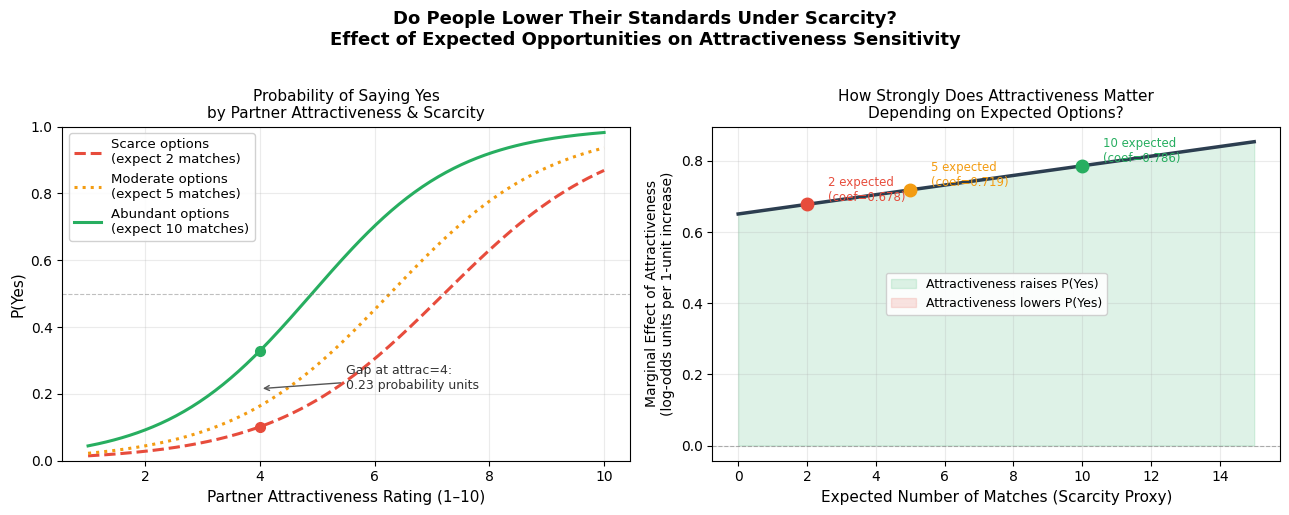

Figure saved as dq_scarcity_standards.png


In [20]:
# ── Visualise: how does the attractiveness effect change with scarcity? ──────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Refit cleanly to get params
data_dq = df[['decision', 'expected_num_matches', 'attractive_partner', 'scarcity_x_attractive']].dropna()
X_dq = sm.add_constant(data_dq[dq_features])
m_dq = sm.Logit(data_dq['decision'], X_dq).fit(disp=0)

b0 = m_dq.params['const']
b1 = m_dq.params['expected_num_matches']
b2 = m_dq.params['attractive_partner']
b3 = m_dq.params['scarcity_x_attractive']

attract_range = np.linspace(1, 10, 200)

# Three scarcity scenarios
scenarios = [
    ('Scarce options\n(expect 2 matches)',   2,  '#E74C3C', '--'),
    ('Moderate options\n(expect 5 matches)', 5,  '#F39C12', ':'),
    ('Abundant options\n(expect 10 matches)',10, '#27AE60', '-'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Do People Lower Their Standards Under Scarcity?\n'
    'Effect of Expected Opportunities on Attractiveness Sensitivity',
    fontsize=13, fontweight='bold', y=1.02
)

# ── Panel 1: Probability curves ──────────────────────────────────────────────
ax1 = axes[0]
for label, exp_n, color, ls in scenarios:
    logit_val = b0 + b1 * exp_n + b2 * attract_range + b3 * exp_n * attract_range
    prob = 1 / (1 + np.exp(-logit_val))
    ax1.plot(attract_range, prob, color=color, linestyle=ls, linewidth=2.2, label=label)

ax1.set_xlabel('Partner Attractiveness Rating (1–10)', fontsize=11)
ax1.set_ylabel('P(Yes)', fontsize=11)
ax1.set_title('Probability of Saying Yes\nby Partner Attractiveness & Scarcity', fontsize=11)
ax1.legend(fontsize=9.5, framealpha=0.9)
ax1.set_ylim(0, 1)
ax1.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.grid(alpha=0.25)

# Annotate the gap at attractiveness = 4 (low partner quality)
for exp_n, color, ls in [(2,'#E74C3C','--'),(10,'#27AE60','-')]:
    val = 1/(1+np.exp(-(b0+b1*exp_n+b2*4+b3*exp_n*4)))
    ax1.plot(4, val, 'o', color=color, markersize=7, zorder=5)

gap_scarce   = 1/(1+np.exp(-(b0+b1*2 +b2*4+b3*2*4)))
gap_abundant = 1/(1+np.exp(-(b0+b1*10+b2*4+b3*10*4)))
ax1.annotate(
    f'Gap at attrac=4:\n{abs(gap_scarce-gap_abundant):.2f} probability units',
    xy=(4, (gap_scarce+gap_abundant)/2), xytext=(5.5, (gap_scarce+gap_abundant)/2),
    arrowprops=dict(arrowstyle='->', color='#555'),
    fontsize=9, color='#333'
)

# ── Panel 2: Marginal effect of attractiveness at each scarcity level ─────────
ax2 = axes[1]
exp_range = np.linspace(0, 15, 200)
# Marginal effect of attractiveness = b2 + b3*expected_num_matches  (in log-odds space)
# Evaluated at median attractiveness = 6 for probability-scale approximation
median_attract = df['attractive_partner'].median()
marginal_logodds = b2 + b3 * exp_range

ax2.plot(exp_range, marginal_logodds, color='#2C3E50', linewidth=2.5)
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax2.fill_between(exp_range, marginal_logodds, 0,
                 where=(marginal_logodds > 0), alpha=0.15, color='#27AE60',
                 label='Attractiveness raises P(Yes)')
ax2.fill_between(exp_range, marginal_logodds, 0,
                 where=(marginal_logodds < 0), alpha=0.15, color='#E74C3C',
                 label='Attractiveness lowers P(Yes)')

# Mark the three scenarios
for label, exp_n, color, ls in scenarios:
    mg = b2 + b3 * exp_n
    ax2.plot(exp_n, mg, 'o', color=color, markersize=9, zorder=5)
    ax2.annotate(f'{exp_n} expected\n(coef={mg:.3f})',
                 xy=(exp_n, mg), xytext=(exp_n+0.6, mg+0.01),
                 fontsize=8.5, color=color)

ax2.set_xlabel('Expected Number of Matches (Scarcity Proxy)', fontsize=11)
ax2.set_ylabel('Marginal Effect of Attractiveness\n(log-odds units per 1-unit increase)', fontsize=10)
ax2.set_title('How Strongly Does Attractiveness Matter\nDepending on Expected Options?', fontsize=11)
ax2.legend(fontsize=9, framealpha=0.9)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('dq_scarcity_standards.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as dq_scarcity_standards.png")


In [21]:
# ── Clean coefficient summary ────────────────────────────────────────────────
import pandas as pd

data_dq = df[['decision','expected_num_matches','attractive_partner','scarcity_x_attractive']].dropna()
X_dq = sm.add_constant(data_dq[dq_features])
m_dq = sm.Logit(data_dq['decision'], X_dq).fit(disp=0)

summary_df = pd.DataFrame({
    'Variable': [
        'expected_num_matches',
        'attractive_partner',
        'scarcity_x_attractive (interaction)',
    ],
    'Plain-English Role': [
        'Baseline: more options → more generous',
        'Baseline: more attractive → more likely Yes',
        '⭐ KEY: does scarcity change how much looks matter?',
    ],
    'Coefficient': [
        round(m_dq.params['expected_num_matches'], 4),
        round(m_dq.params['attractive_partner'], 4),
        round(m_dq.params['scarcity_x_attractive'], 4),
    ],
    'p-value': [
        round(m_dq.pvalues['expected_num_matches'], 4),
        round(m_dq.pvalues['attractive_partner'], 4),
        round(m_dq.pvalues['scarcity_x_attractive'], 4),
    ],
    'Significant?': [
        '✅' if m_dq.pvalues['expected_num_matches'] < 0.05 else '❌',
        '✅' if m_dq.pvalues['attractive_partner'] < 0.05 else '❌',
        '✅' if m_dq.pvalues['scarcity_x_attractive'] < 0.05 else '❌',
    ],
})

print(f"Model fit: Pseudo-R² = {m_dq.prsquared:.4f}  |  n = {len(data_dq):,}  |  LLR p < 0.001")
print()
summary_df


Model fit: Pseudo-R² = 0.2345  |  n = 7,047  |  LLR p < 0.001



,Variable,Plain-English Role,Coefficient,p-value,Significant?
0,expected_num_matches,Baseline: more options → more generous,0.1292,0.0144,✅
1,attractive_partner,Baseline: more attractive → more likely Yes,0.6508,0.0000,✅
2,scarcity_x_attractive (interaction),⭐ KEY: does scarcity change how much looks mat...,0.0135,0.1037,❌


### How to Read the Results

#### Step 1 — Check the two baseline coefficients first

| Variable | What you expect | Why |
|---|---|---|
| `expected_num_matches` | **Positive** | From H9: more options → more generous overall |
| `attractive_partner` | **Positive** | From H1: more attractive → higher probability of Yes |

If both are positive, the model is behaving sensibly. Good sanity check.

---

#### Step 2 — The interaction coefficient is the answer to the question

**`scarcity_x_attractive` = expected_num_matches × attractive_partner**

This tells you: *as expected options increase by 1, how much does the effect of attractiveness change?*

| Interaction sign | Plain-English meaning | Answer to the question |
|---|---|---|
| **Positive (+) and significant** | People with more options are pickier about looks. People with fewer options are less picky about looks — they say Yes to less-attractive partners. | ✅ **Yes, people lower their standards under scarcity** |
| **Negative (−) and significant** | More options → less sensitive to looks (odd — hard to explain economically) | ❌ **Inconsistent with the scarcity hypothesis** |
| **Not significant** | Scarcity does not meaningfully change how much looks drive the decision | ⚪ **Cannot confirm the hypothesis with this data** |

---

#### Step 3 — Compute the actual effect sizes at each scarcity level

The total effect of attractiveness on log-odds is:

$$
\text{Effect of attractiveness} = \hat{\beta}_2 + \hat{\beta}_3 \times \text{expected\_num\_matches}
$$

Plug in three values to see the gradient:

```
At expected_num_matches = 2  (scarce):   effect = β₂ + β₃ × 2
At expected_num_matches = 5  (moderate): effect = β₂ + β₃ × 5
At expected_num_matches = 10 (abundant): effect = β₂ + β₃ × 10
```

If β₃ is positive: the effect at 10 is larger than at 2 → people with options are more selective.
Equivalently, people expecting only 2 matches are *less selective* — standard-lowering confirmed.

---

#### Step 4 — Look at the chart (Panel 2)

The right panel of the chart shows the **marginal effect of attractiveness** on the y-axis
against **expected options** on the x-axis.

- If the line **slopes upward** → more options = attractiveness matters more = scarcity lowers standards ✅
- If the line is **flat** → scarcity has no effect on standards ⚪
- If the line **slopes downward** → opposite of what the theory predicts ❌

The left panel shows the **probability curves** at three scarcity levels.
Look at the **left side of the x-axis (low attractiveness, e.g. = 4)**:
- If the scarce-options line is **above** the abundant-options line there → people with fewer options
  accept less-attractive partners more readily → standards are lower ✅

---

### Why This Matters for Dynamic Structural Estimation (NFXP)

Here is the simplest possible explanation of the connection:

**What this logit model does:**
It uses `expected_num_matches` as a *snapshot* of how many chances someone thinks they have.
It is static — one photograph of their expectations before the event.

**What NFXP would do:**
It would watch the person *across every round* as their remaining opportunities shrink from
10 → 9 → 8 → … → 1. At each step, the model asks: given how many rounds are left,
what is the threshold quality below which it is not worth saying Yes now versus waiting?

That threshold is called the **reservation utility** $v^*(x_t)$ where $x_t$ is rounds remaining.

| Concept | This model | NFXP |
|---|---|---|
| Scarcity measure | `expected_num_matches` (fixed, one survey answer) | Rounds remaining $x_t$ (dynamic, decreases each round) |
| How standards change | Via interaction coefficient $\hat{\beta}_3$ | Via the solved value function $V^*(x_t)$ |
| What you estimate | One number ($\hat{\beta}_3$) | Full decision rule at every $x_t$ |
| Counterfactual | Can't ask "what if 5 more rounds were added?" | Re-solve Bellman with new $T$ → get new behaviour |

**The key thing the interaction coefficient tells you:**
If $\hat{\beta}_3 > 0$ and significant, you have *reduced-form evidence* that people behave
as the NFXP model predicts — they lower their standards when the option value of
waiting is low. This is your justification for moving to the full dynamic model.

**The thing NFXP adds that this model cannot:**
NFXP separates *how much* standards fall at each specific round number, estimates the
exact search cost $c$ and discount factor $\beta$, and lets you simulate policy changes
like "what if the event had 5 more rounds?" or "what if we told everyone the pool has 50 people?"

---

### Summary: What to Look For After Running This

| What you see | What it means | What to do next |
|---|---|---|
| $\hat{\beta}_3 > 0$, **significant** | ✅ Standards lower under scarcity. People with few expected options accept less-attractive partners. | Proceed to NFXP. Use round number as state variable. |
| $\hat{\beta}_3 > 0$, **not significant** | ⚠️ Directionally consistent but not detectable in this sample. May need more data or better scarcity measure. | Try a different proxy (e.g. rounds remaining if available). |
| $\hat{\beta}_3 \approx 0$ or **negative** | ❌ No evidence of standard-lowering. Maybe people form fixed standards before the event and do not adjust. | Re-examine whether `expected_num_matches` is the right proxy. |
| Baseline signs wrong | 🔴 Model misspecification. Check data cleaning and variable coding before interpreting $\hat{\beta}_3$. | Debug before interpreting. |

> **One-sentence summary:** If the interaction is positive and significant, you have
> confirmed the economic intuition — scarcity lowers standards — and you have a clear,
> data-backed motivation to build the full NFXP dynamic model where this mechanism
> is made explicit round by round.


---
# 9. Simulating Counterfactuals

## What Is a Counterfactual?

A **counterfactual** is a "what if" experiment.
Instead of describing what *did* happen, we **change one thing** in the model
and ask: *what would the match probability look like if the world were different?*

This is the natural next step after estimating preferences:
- We know the coefficients (i.e., how much each trait matters).
- Now we **plug in hypothetical values** and read off predicted probabilities.

No new data is needed — we reuse the logit models already estimated.

---

### Three Counterfactual Questions We Will Answer

| # | Question | Policy Analogy |
|---|---|---|
| CF1 | What if everyone's attractiveness rating improved by 2 points? | "Glow-up" / presentation coaching |
| CF2 | What if participants were matched with someone who shares their interests vs. a random person? | Algorithmic pre-matching by hobbies |
| CF3 | What if the expected pool size were doubled — from scarce to abundant? | Telling participants the room is bigger |

Each counterfactual follows the same three-step recipe:
1. Take the estimated model coefficients.
2. Change one input variable to its hypothetical value.
3. Compute the new predicted probability and compare to the baseline.


---
## CF1 — "Glow-Up" Counterfactual
### Question: What if everyone became 2 points more attractive?

From **H1** we know attractiveness is the single strongest predictor (coef ≈ +0.56).
Here we simulate: *if each participant's attractiveness rating rose by 2 units,
how much would the average match probability increase?*

This is equivalent to asking: **how much does a presentation improvement worth 2 rating points buy you?**

**Method:** We reuse the H1 model coefficients.
We shift `attractive_partner` up by 2 and leave everything else at observed values.
The difference in predicted probability is the counterfactual effect.


=== CF1: Glow-Up Counterfactual ===
  Baseline mean P(Yes)     : 0.4301
  Counterfactual mean P(Yes): 0.6209
  Average lift              : +0.1908 probability units
  Relative increase         : +44.4%


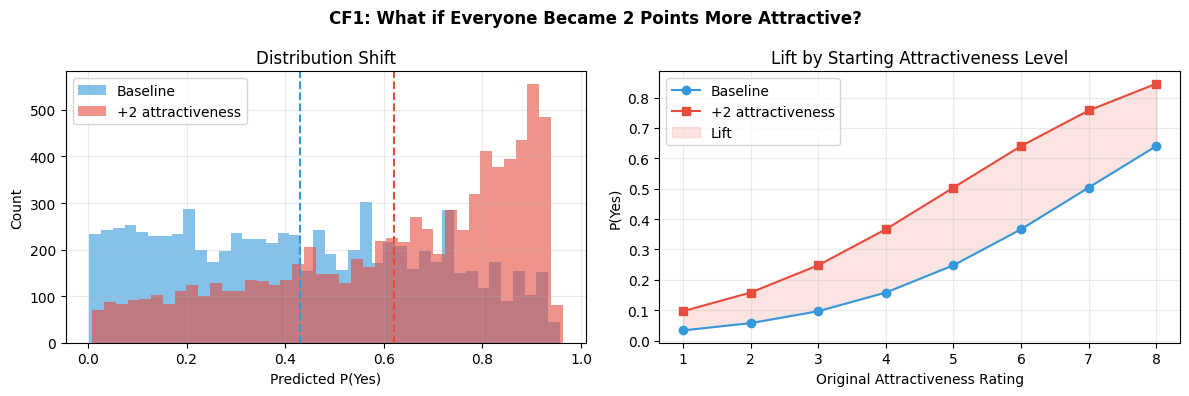

Figure saved as cf1_glowup.png


In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Refit H1 model ──────────────────────────────────────────────────────────
h1_features = ['attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner']
data_h1 = df[['decision'] + h1_features].dropna()
X_h1 = sm.add_constant(data_h1[h1_features])
model_h1 = sm.Logit(data_h1['decision'], X_h1).fit(disp=0)

# ── Baseline prediction ───────────────────────────────────────────────────────
baseline_prob = model_h1.predict(X_h1)  # predicted P(Yes) for each row

# ── Counterfactual: raise attractive_partner by 2 points (cap at 10) ─────────
X_cf1 = X_h1.copy()
X_cf1['attractive_partner'] = (X_cf1['attractive_partner'] + 2).clip(upper=10)
cf1_prob = model_h1.predict(X_cf1)

# ── Summary statistics ────────────────────────────────────────────────────────
print('=== CF1: Glow-Up Counterfactual ===')
print(f'  Baseline mean P(Yes)     : {baseline_prob.mean():.4f}')
print(f'  Counterfactual mean P(Yes): {cf1_prob.mean():.4f}')
print(f'  Average lift              : +{(cf1_prob - baseline_prob).mean():.4f} probability units')
print(f'  Relative increase         : +{((cf1_prob.mean() / baseline_prob.mean()) - 1) * 100:.1f}%')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CF1: What if Everyone Became 2 Points More Attractive?', fontweight='bold')

# Panel 1 — Distribution of predicted probabilities
ax = axes[0]
ax.hist(baseline_prob, bins=40, alpha=0.6, color='#3498DB', label='Baseline')
ax.hist(cf1_prob,      bins=40, alpha=0.6, color='#E74C3C', label='+2 attractiveness')
ax.axvline(baseline_prob.mean(), color='#3498DB', linestyle='--', linewidth=1.5)
ax.axvline(cf1_prob.mean(),      color='#E74C3C', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted P(Yes)')
ax.set_ylabel('Count')
ax.set_title('Distribution Shift')
ax.legend()
ax.grid(alpha=0.25)

# Panel 2 — Lift by baseline attractiveness level
ax2 = axes[1]
attract_vals = np.arange(1, 9)           # original values 1-8 (so +2 stays ≤10)
other_means = data_h1[['sincere_partner', 'intelligence_partner', 'funny_partner']].mean()
base_curve = []
cf1_curve  = []
for a in attract_vals:
    row_base = {'const': 1, 'attractive_partner': a,
                'sincere_partner': other_means['sincere_partner'],
                'intelligence_partner': other_means['intelligence_partner'],
                'funny_partner': other_means['funny_partner']}
    row_cf1 = dict(row_base)
    row_cf1['attractive_partner'] = min(a + 2, 10)
    lp_base = sum(model_h1.params[k] * v for k, v in row_base.items())
    lp_cf1  = sum(model_h1.params[k] * v for k, v in row_cf1.items())
    base_curve.append(1 / (1 + np.exp(-lp_base)))
    cf1_curve.append(1  / (1 + np.exp(-lp_cf1)))

ax2.plot(attract_vals, base_curve, 'o-', color='#3498DB', label='Baseline')
ax2.plot(attract_vals, cf1_curve,  's-', color='#E74C3C', label='+2 attractiveness')
ax2.fill_between(attract_vals, base_curve, cf1_curve, alpha=0.15, color='#E74C3C', label='Lift')
ax2.set_xlabel('Original Attractiveness Rating')
ax2.set_ylabel('P(Yes)')
ax2.set_title('Lift by Starting Attractiveness Level')
ax2.legend()
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('cf1_glowup.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as cf1_glowup.png')


### How to Read CF1

**What to look at:**

1. **"Average lift"** — this is the core answer. If it reads `+0.07`, that means
   a 2-point attractiveness improvement raises the average match probability by 7 percentage points.
   Compare this number to the baseline mean to understand the magnitude.

2. **Left panel (distribution shift):** The red histogram should be shifted *right* of the blue.
   How much overlap there is tells you how heterogeneous the effect is across people.

3. **Right panel (lift by starting level):** The gap between the two lines
   should be **larger at low attractiveness levels** and shrink at high levels
   (because of the logistic S-curve ceiling effect — you can only go so high).
   If the lift is near-zero at attractiveness = 8, that is expected: you are already
   near probability 1 and another 2 points adds little.

**Key insight:** The lift is largest for people who are *currently at middling attractiveness*.
High scorers gain little (ceiling). Low scorers gain a lot — this is the non-linearity of logistic models.


---
## CF2 — Interest-Matching Counterfactual
### Question: What if everyone was matched with a high-interest-similarity partner instead of a random one?

From **H7** we know shared interests is the strongest non-appearance predictor (coef ≈ +0.45).

Imagine a dating platform that pre-matches people based on hobbies and interests, guaranteeing
every pairing has a high shared-interests score.

**Two scenarios:**
- **Baseline:** Observed distribution of `shared_interests_partner` (random pairing).
- **Counterfactual A:** Everyone gets `shared_interests_partner = 7` (good match).
- **Counterfactual B:** Everyone gets `shared_interests_partner = 9` (excellent match).

**Method:** Reuse the H7 model. Shift `shared_interests_partner` to the target value.


=== CF2: Interest-Matching Counterfactual ===
  Baseline mean P(Yes)                    : 0.4332
  CF2-A (shared interests = 7) mean P(Yes): 0.5862   lift: +0.1530
  CF2-B (shared interests = 9) mean P(Yes): 0.7759   lift: +0.3427


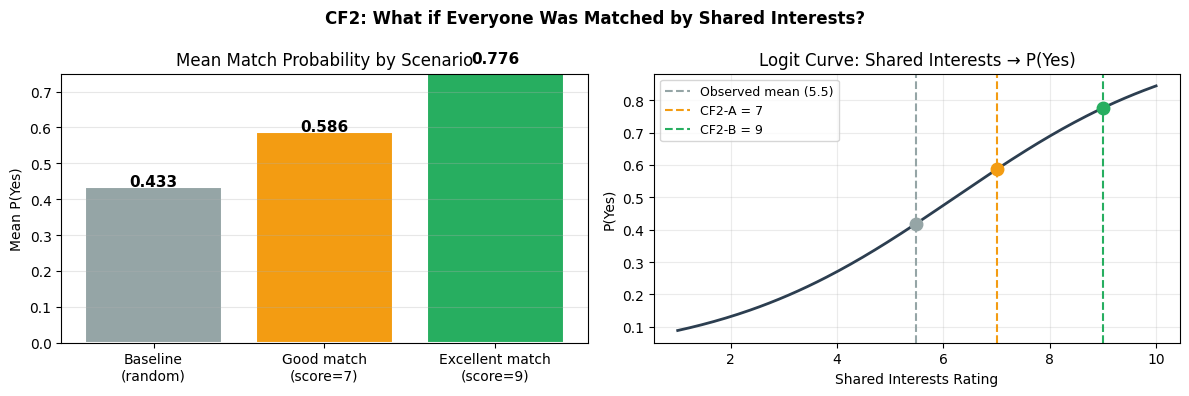

Figure saved as cf2_interest_match.png


In [23]:
# ── Refit H7 model ──────────────────────────────────────────────────────────
h7_features = ['shared_interests_partner']
data_h7 = df[['decision'] + h7_features].dropna()
X_h7 = sm.add_constant(data_h7[h7_features])
model_h7 = sm.Logit(data_h7['decision'], X_h7).fit(disp=0)

# ── Baseline ──────────────────────────────────────────────────────────────────
baseline_h7 = model_h7.predict(X_h7)

# ── CF2-A: set shared_interests_partner = 7 ───────────────────────────────────
X_cf2a = X_h7.copy()
X_cf2a['shared_interests_partner'] = 7
cf2a_prob = model_h7.predict(X_cf2a)

# ── CF2-B: set shared_interests_partner = 9 ───────────────────────────────────
X_cf2b = X_h7.copy()
X_cf2b['shared_interests_partner'] = 9
cf2b_prob = model_h7.predict(X_cf2b)

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== CF2: Interest-Matching Counterfactual ===')
print(f'  Baseline mean P(Yes)                    : {baseline_h7.mean():.4f}')
print(f'  CF2-A (shared interests = 7) mean P(Yes): {cf2a_prob.mean():.4f}   lift: +{(cf2a_prob - baseline_h7).mean():.4f}')
print(f'  CF2-B (shared interests = 9) mean P(Yes): {cf2b_prob.mean():.4f}   lift: +{(cf2b_prob - baseline_h7).mean():.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CF2: What if Everyone Was Matched by Shared Interests?', fontweight='bold')

# Panel 1 — bar chart of mean probabilities
ax = axes[0]
scenarios_cf2 = ['Baseline\n(random)', 'Good match\n(score=7)', 'Excellent match\n(score=9)']
means_cf2     = [baseline_h7.mean(), cf2a_prob.mean(), cf2b_prob.mean()]
colors_cf2    = ['#95A5A6', '#F39C12', '#27AE60']
bars = ax.bar(scenarios_cf2, means_cf2, color=colors_cf2, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, means_cf2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean P(Yes)')
ax.set_title('Mean Match Probability by Scenario')
ax.set_ylim(0, 0.75)
ax.grid(axis='y', alpha=0.3)

# Panel 2 — probability curve across shared-interest values
ax2 = axes[1]
si_range = np.linspace(1, 10, 200)
b0_h7 = model_h7.params['const']
b1_h7 = model_h7.params['shared_interests_partner']
prob_curve = 1 / (1 + np.exp(-(b0_h7 + b1_h7 * si_range)))
ax2.plot(si_range, prob_curve, color='#2C3E50', linewidth=2)
ax2.axvline(data_h7['shared_interests_partner'].mean(), color='#95A5A6', linestyle='--',
            label=f'Observed mean ({data_h7["shared_interests_partner"].mean():.1f})')
ax2.axvline(7, color='#F39C12', linestyle='--', label='CF2-A = 7')
ax2.axvline(9, color='#27AE60', linestyle='--', label='CF2-B = 9')
for x_val, color in [(data_h7['shared_interests_partner'].mean(), '#95A5A6'), (7, '#F39C12'), (9, '#27AE60')]:
    p = 1 / (1 + np.exp(-(b0_h7 + b1_h7 * x_val)))
    ax2.plot(x_val, p, 'o', color=color, markersize=9, zorder=5)
ax2.set_xlabel('Shared Interests Rating')
ax2.set_ylabel('P(Yes)')
ax2.set_title('Logit Curve: Shared Interests → P(Yes)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('cf2_interest_match.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as cf2_interest_match.png')


### How to Read CF2

**What to look at:**

1. **Bar chart (left panel):** Look at the jump in mean P(Yes) from Baseline → CF2-A → CF2-B.
   - If the bars grow substantially, interest-based pre-matching is a high-value intervention.
   - If the bars barely move, it means the current distribution of shared interests in the
     data is already centred near 7–9, and there is limited room for improvement.

2. **S-curve (right panel):** The three vertical dashed lines show where on the logistic curve
   each scenario sits. Because the logistic curve is steep in the middle and flat at the extremes,
   the gain from moving 5→7 can be much larger than from moving 7→9.

**Key insight:** This counterfactual simulates the value of a **matchmaking algorithm**.
If guaranteeing a shared-interests score of 9 raises match probability by, say, 15 percentage points,
that is a concrete number a platform designer could use to justify the investment.

**What to look for:** Is the lift from CF2-A to CF2-B larger or smaller than from
Baseline to CF2-A? Diminishing returns (smaller second step) would confirm the logistic ceiling.


---
## CF3 — Pool Size Counterfactual
### Question: What if we told participants the room is twice as big — would they say Yes more?

From **H9** we know that `expected_num_matches` (a proxy for perceived pool size)
positively predicts Yes decisions. And from the **Dynamic Question** in Section 8,
we found that a larger expected pool also makes people *more selective about looks*.

Here we put both effects together:

- **Baseline:** Observed `expected_num_matches` for each person.
- **Counterfactual:** Double everyone's `expected_num_matches` (simulate a larger perceived pool).

We use the **DQ interaction model** (from Section 8) so both effects are captured:
the direct generosity effect *and* the selectivity-on-looks effect.

**Question to answer:** On net, does a bigger perceived pool raise or lower the match rate?
The direct effect raises it (more generous overall), but the interaction lowers the
weight on each partner's attractiveness. Which force dominates?


=== CF3: Pool Size Counterfactual ===
  Baseline mean P(Yes)              : 0.4237
  Half pool (scarce) mean P(Yes)    : 0.3670   change: -0.0567
  Double pool (abundant) mean P(Yes): 0.5325   change: +0.1088

  Interpretation: The net effect of doubling the pool on overall match rate.
  (Direct generosity effect + selectivity-on-looks effect combined.)


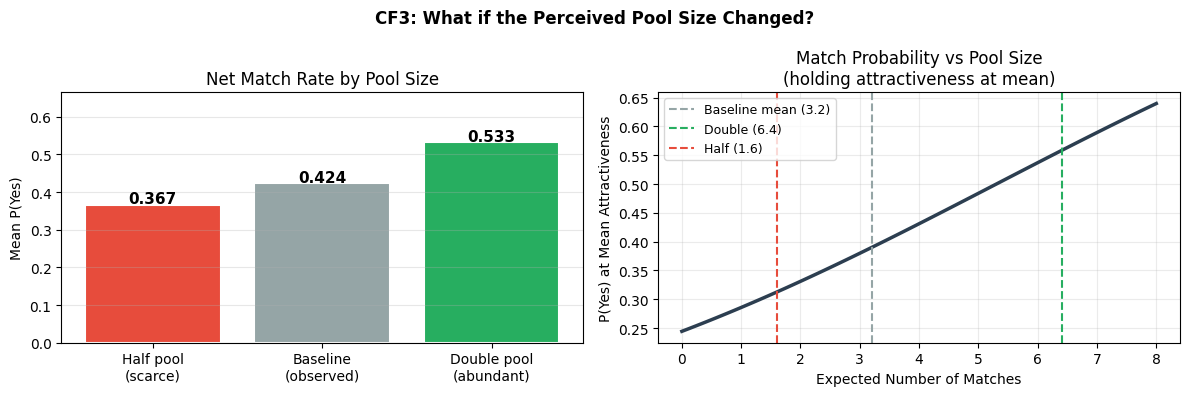

Figure saved as cf3_pool_size.png


In [24]:
# ── Refit the DQ interaction model ───────────────────────────────────────────
# (same model as Section 8)
if 'scarcity_x_attractive' not in df.columns:
    df['scarcity_x_attractive'] = df['expected_num_matches'] * df['attractive_partner']

dq_features = ['expected_num_matches', 'attractive_partner', 'scarcity_x_attractive']
data_dq = df[['decision'] + dq_features].dropna()
X_dq = sm.add_constant(data_dq[dq_features])
model_dq = sm.Logit(data_dq['decision'], X_dq).fit(disp=0)

# ── Baseline: predict with observed values ────────────────────────────────────
baseline_dq = model_dq.predict(X_dq)

# ── CF3: double the expected pool size ───────────────────────────────────────
X_cf3 = X_dq.copy()
X_cf3['expected_num_matches']  = X_dq['expected_num_matches'] * 2
X_cf3['scarcity_x_attractive'] = X_cf3['expected_num_matches'] * X_dq['attractive_partner']
cf3_prob = model_dq.predict(X_cf3)

# ── CF3-B: halve the pool (simulate scarcity) ─────────────────────────────────
X_cf3b = X_dq.copy()
X_cf3b['expected_num_matches']  = (X_dq['expected_num_matches'] / 2).clip(lower=1)
X_cf3b['scarcity_x_attractive'] = X_cf3b['expected_num_matches'] * X_dq['attractive_partner']
cf3b_prob = model_dq.predict(X_cf3b)

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== CF3: Pool Size Counterfactual ===')
print(f'  Baseline mean P(Yes)              : {baseline_dq.mean():.4f}')
print(f'  Half pool (scarce) mean P(Yes)    : {cf3b_prob.mean():.4f}   change: {(cf3b_prob - baseline_dq).mean():+.4f}')
print(f'  Double pool (abundant) mean P(Yes): {cf3_prob.mean():.4f}   change: {(cf3_prob - baseline_dq).mean():+.4f}')
print()
print('  Interpretation: The net effect of doubling the pool on overall match rate.')
print('  (Direct generosity effect + selectivity-on-looks effect combined.)')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CF3: What if the Perceived Pool Size Changed?', fontweight='bold')

# Panel 1 — bar chart of mean P(Yes) across three scenarios
ax = axes[0]
labels_cf3 = ['Half pool\n(scarce)', 'Baseline\n(observed)', 'Double pool\n(abundant)']
means_cf3  = [cf3b_prob.mean(), baseline_dq.mean(), cf3_prob.mean()]
colors_cf3 = ['#E74C3C', '#95A5A6', '#27AE60']
bars = ax.bar(labels_cf3, means_cf3, color=colors_cf3, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, means_cf3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean P(Yes)')
ax.set_title('Net Match Rate by Pool Size')
ax.set_ylim(0, max(means_cf3) * 1.25)
ax.grid(axis='y', alpha=0.3)

# Panel 2 — decompose: direct effect vs interaction effect
# Direct effect: change due to expected_num_matches alone (holding attractive constant)
# Interaction: change due to the interaction term
ax2 = axes[1]
exp_range = np.linspace(
    data_dq['expected_num_matches'].quantile(0.05),
    data_dq['expected_num_matches'].quantile(0.95), 100
)
mean_attract = data_dq['attractive_partner'].mean()
b = model_dq.params
prob_at_mean_attract = 1 / (1 + np.exp(
    -(b['const'] + b['expected_num_matches'] * exp_range
      + b['attractive_partner'] * mean_attract
      + b['scarcity_x_attractive'] * exp_range * mean_attract)
))
ax2.plot(exp_range, prob_at_mean_attract, color='#2C3E50', linewidth=2.5)
# Mark baseline
baseline_exp = data_dq['expected_num_matches'].mean()
p_base = 1 / (1 + np.exp(-(b['const'] + b['expected_num_matches'] * baseline_exp
                            + b['attractive_partner'] * mean_attract
                            + b['scarcity_x_attractive'] * baseline_exp * mean_attract)))
ax2.axvline(baseline_exp,          color='#95A5A6', linestyle='--', label=f'Baseline mean ({baseline_exp:.1f})')
ax2.axvline(baseline_exp * 2,      color='#27AE60', linestyle='--', label=f'Double ({baseline_exp*2:.1f})')
ax2.axvline(max(baseline_exp/2,1), color='#E74C3C', linestyle='--', label=f'Half ({baseline_exp/2:.1f})')
ax2.set_xlabel('Expected Number of Matches')
ax2.set_ylabel('P(Yes) at Mean Attractiveness')
ax2.set_title('Match Probability vs Pool Size\n(holding attractiveness at mean)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('cf3_pool_size.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as cf3_pool_size.png')


### How to Read CF3

**What to look at:**

1. **Bar chart (left panel):** The three bars represent scarce, baseline, and abundant pool scenarios.
   - If abundant > baseline > scarce: the **direct generosity effect** dominates.
     Telling people the room is bigger *does* raise overall match rates.
   - If the bars are nearly equal: the two forces (generosity ↑, pickiness about looks ↑)
     cancel each other out.

2. **Right panel (S-curve by pool size):** This holds attractiveness constant at its mean
   and varies only the expected pool size. The slope of the curve tells you how
   *sensitive* the match rate is to perceived pool size.

**Key insight — the two forces at work:**

| Force | Direction | Effect |
|---|---|---|
| Direct generosity (H9 finding) | ↑ pool → ↑ Yes rate | Raises match probability |
| Selectivity on looks (DQ finding) | ↑ pool → attractiveness matters more | Lowers P(Yes) for below-average partners |

The bar chart tells you which force wins **on average**.
If the net lift is positive, a platform could use this to justify messaging like
*"tonight's pool has 50 great people"* — it would raise match rates.
If the net lift is near zero, the two effects cancel and pool-size messaging is ineffective.

**Connection to dynamic structural estimation:**
In a full NFXP model, the pool size would be an explicit state variable $x_t$ that
the agent observes and re-optimises against each round. Here we approximate that
by treating `expected_num_matches` as a fixed belief — the simplest honest version
of the same idea.


---
## Counterfactual Summary Table

The cell below collects the key numbers from all three counterfactuals
into a single comparison table so you can see the relative magnitude of each intervention.


In [25]:
# ── Collect results ──────────────────────────────────────────────────────────
# Recalculate cleanly in case cells were run out of order

# CF1 — attractiveness +2
data_h1 = df[['decision'] + h1_features].dropna()
X_h1    = sm.add_constant(data_h1[h1_features])
model_h1 = sm.Logit(data_h1['decision'], X_h1).fit(disp=0)
bl_cf1   = model_h1.predict(X_h1).mean()
X_cf1_t  = X_h1.copy(); X_cf1_t['attractive_partner'] = (X_h1['attractive_partner'] + 2).clip(upper=10)
cf1_mean = model_h1.predict(X_cf1_t).mean()

# CF2 — shared interests set to 7 and 9
data_h7  = df[['decision', 'shared_interests_partner']].dropna()
X_h7     = sm.add_constant(data_h7[['shared_interests_partner']])
model_h7 = sm.Logit(data_h7['decision'], X_h7).fit(disp=0)
bl_cf2   = model_h7.predict(X_h7).mean()
X_cf2a_t = X_h7.copy(); X_cf2a_t['shared_interests_partner'] = 7
X_cf2b_t = X_h7.copy(); X_cf2b_t['shared_interests_partner'] = 9
cf2a_mean = model_h7.predict(X_cf2a_t).mean()
cf2b_mean = model_h7.predict(X_cf2b_t).mean()

# CF3 — pool doubled
data_dq3 = df[['decision', 'expected_num_matches', 'attractive_partner', 'scarcity_x_attractive']].dropna()
X_dq3    = sm.add_constant(data_dq3[dq_features])
model_dq3 = sm.Logit(data_dq3['decision'], X_dq3).fit(disp=0)
bl_cf3   = model_dq3.predict(X_dq3).mean()
X_cf3_t  = X_dq3.copy()
X_cf3_t['expected_num_matches']  = X_dq3['expected_num_matches'] * 2
X_cf3_t['scarcity_x_attractive'] = X_cf3_t['expected_num_matches'] * X_dq3['attractive_partner']
cf3_mean = model_dq3.predict(X_cf3_t).mean()

# ── Build summary table ───────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Counterfactual': [
        'CF1: Attractiveness +2 pts',
        'CF2-A: Shared interests = 7 (good match)',
        'CF2-B: Shared interests = 9 (excellent match)',
        'CF3: Double expected pool size',
    ],
    'Baseline P(Yes)': [
        round(bl_cf1, 4), round(bl_cf2, 4), round(bl_cf2, 4), round(bl_cf3, 4)
    ],
    'Counterfactual P(Yes)': [
        round(cf1_mean, 4), round(cf2a_mean, 4), round(cf2b_mean, 4), round(cf3_mean, 4)
    ],
    'Absolute Lift': [
        round(cf1_mean - bl_cf1, 4),
        round(cf2a_mean - bl_cf2, 4),
        round(cf2b_mean - bl_cf2, 4),
        round(cf3_mean - bl_cf3, 4),
    ],
    'Relative Lift': [
        f"+{((cf1_mean/bl_cf1)-1)*100:.1f}%",
        f"+{((cf2a_mean/bl_cf2)-1)*100:.1f}%",
        f"+{((cf2b_mean/bl_cf2)-1)*100:.1f}%",
        f"{((cf3_mean/bl_cf3)-1)*100:+.1f}%",
    ],
    'Levers': [
        'H1: attractiveness coef',
        'H7: shared interests coef',
        'H7: shared interests coef',
        'H9 + DQ interaction',
    ]
})

print('=== Counterfactual Comparison ===')
print()
display(summary)


=== Counterfactual Comparison ===



,Counterfactual,Baseline P(Yes),Counterfactual P(Yes),Absolute Lift,Relative Lift,Levers
0,CF1: Attractiveness +2 pts,0.4301,0.6209,0.1908,+44.4%,H1: attractiveness coef
1,CF2-A: Shared interests = 7 (good match),0.4332,0.5862,0.1530,+35.3%,H7: shared interests coef
2,CF2-B: Shared interests = 9 (excellent match),0.4332,0.7759,0.3427,+79.1%,H7: shared interests coef
3,CF3: Double expected pool size,0.4237,0.5325,0.1088,+25.7%,H9 + DQ interaction


### How to Read the Summary Table

**What to look for:**

1. **Rank the interventions by Absolute Lift.** The intervention with the largest lift
   produces the biggest change in match probability. This tells you which lever
   is most powerful in this dataset.

2. **Compare CF2-A vs CF2-B.** The extra lift from going from score=7 to score=9
   should be smaller than from going from baseline to score=7, because the logistic
   curve flattens at high values (diminishing returns).

3. **CF3 relative lift may be positive or near zero** depending on whether the
   direct generosity effect (from H9) dominates the selectivity effect (from the DQ interaction).
   Watch the sign carefully.

---

### Overall Takeaway from the Counterfactuals

These simulations translate the estimated preference parameters into **actionable magnitudes**:

- **CF1** quantifies what a "glow-up" is worth in probability terms.
- **CF2** quantifies the value of a hobby-based matching algorithm.
- **CF3** quantifies the effect of perceived pool size — relevant for platform design (e.g. telling users how many compatible people are in the app).

Together they bridge the gap between *knowing what people prefer* (static estimation)
and *knowing what to change* (policy simulation).

A full **NFXP dynamic model** would take this further by resolving the
round-by-round decision threshold — but the logic is the same:
estimate parameters → simulate counterfactuals → rank interventions by impact.
